In [1]:
import requests                
from bs4 import BeautifulSoup  
import urllib3                
import pandas as pd
import matplotlib.pyplot as plt


urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://raw.githubusercontent.com/hiksyksy1234/json/main/test.html"

response = requests.get(url, verify=False)

In [2]:
 # 받아온 HTML 텍스트(response.text)를 파이썬이 분석할 수 있는 트리 구조(soup)로 변환합니다.
soup = BeautifulSoup(response.text, 'html.parser')

---
1. stocks에 {'종목명': name, '현재가': price, '변동률': change} 형태로 데이터를 저장합니다.

In [3]:

stocks = []

for row in soup.select('.stock-item'):
    name = row.select_one('.name').text

    # 콤마 제거 후 숫자로 변환
    price = int(row.select_one('.price').text.replace(',', ''))
    change = float(row.select_one('.change').text)
    
    stocks.append({'종목명': name, '현재가': price, '변동률': change})

print(stocks)    


[{'종목명': '삼성전자', '현재가': 72500, '변동률': 2.5}, {'종목명': 'SK하이닉스', '현재가': 141200, '변동률': 5.1}, {'종목명': 'NAVER', '현재가': 210000, '변동률': -1.2}, {'종목명': '카카오', '현재가': 49800, '변동률': 0.8}, {'종목명': 'LG에너지솔루션', '현재가': 385000, '변동률': -3.5}]


---
2. 위에서 만든 stocks를 DataFrame으로 만듭니다.

In [4]:
df = pd.DataFrame(stocks)
print("--- 전체 주식 데이터 ---")
print(df)

--- 전체 주식 데이터 ---
        종목명     현재가  변동률
0      삼성전자   72500  2.5
1    SK하이닉스  141200  5.1
2     NAVER  210000 -1.2
3       카카오   49800  0.8
4  LG에너지솔루션  385000 -3.5


---
3. 변동률이 0보다 큰 종목만 추출

In [5]:
rising_stocks = df[df['변동률'] > 0]
print("\n--- 상승 중인 종목 ---")
print(rising_stocks)



--- 상승 중인 종목 ---
      종목명     현재가  변동률
0    삼성전자   72500  2.5
1  SK하이닉스  141200  5.1
3     카카오   49800  0.8


---
4. 평균 변동률 계산

In [6]:
avg_change = df['변동률'].mean()
print(f"\n시장 전체 평균 변동률: {avg_change:.2f}%")


시장 전체 평균 변동률: 0.74%


---
5. 데이터 시각화 (Visualization)를 위한 한글 깨짐 방지 설정 (Windows 기준: Malgun Gothic)

In [7]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

---
6. 아래와 같은 그림을 조건에 맞게 그립니다.

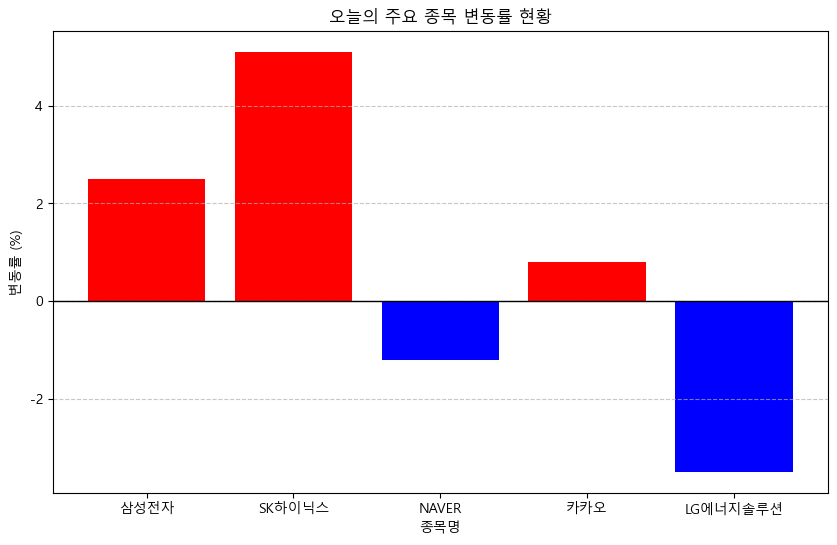

In [10]:
# 그래프 전체 크기를 가로 10인치, 세로 6인치로 설정합니다.
plt.figure(figsize=(10, 6))

# 막대 그래프를 그립니다.
# x축: 종목명
# y축: 변동률
# color 옵션:
#   - 변동률(x)이 0보다 크면 'red' (상승)
#   - 변동률(x)이 0보다 작거나 같으면 'blue' (하락)
plt.bar(df['종목명'], df['변동률'], color=['red' if x > 0 else 'blue' for x in df['변동률']])


# y=0 위치에 기준선(가로선)을 그립니다.
# 주가 상승/하락을 한눈에 구분하기 위한 기준선입니다.
plt.axhline(0, color='black', linewidth=1) # 0선 긋기


# 그래프의 제목을 설정합니다.
plt.title('오늘의 주요 종목 변동률 현황')

# x축의 이름(레이블)을 설정합니다.
plt.xlabel('종목명')


# y축의 이름(레이블)을 설정합니다.
plt.ylabel('변동률 (%)')


# y축 방향으로만 격자(grid)를 표시합니다.
# linestyle='--' : 점선
# alpha=0.7 : 투명도 (0~1, 값이 작을수록 더 투명)
plt.grid(axis='y', linestyle='--', alpha=0.7)


# 지금까지 설정한 그래프를 화면에 출력합니다.
plt.show()

---
7. 상승/하락/보합(status) 컬럼 만들기

- 변동률 > 0 : '상승'

- 변동률 < 0 : '하락'

- 변동률 = 0 : '보합'

In [11]:
df["status"] = df["변동률"].apply(
    lambda x : "상승" if x > 0 else ("하락" if x < 0 else "보합")
)

print(df)

        종목명     현재가  변동률 status
0      삼성전자   72500  2.5     상승
1    SK하이닉스  141200  5.1     상승
2     NAVER  210000 -1.2     하락
3       카카오   49800  0.8     상승
4  LG에너지솔루션  385000 -3.5     하락


---
8. 변동률 Top 3 종목 출력하기

In [ ]:
ans2 = df.sort_values('변동률', ascending=False).head(3)[['종목명', '현재가', '변동률']]
print(ans2)

      종목명     현재가  변동률
1  SK하이닉스  141200  5.1
0    삼성전자   72500  2.5
3     카카오   49800  0.8


---
9. status별 종목 수 / 평균 변동률

In [18]:
pivot_status = df.pivot_table(
    index="status",
    values="변동률",
    aggfunc=['count', 'mean']
)
print(pivot_status)

       count  mean
         변동률   변동률
status            
상승         3  2.80
하락         2 -2.35


---
10. 변동률이 시장 평균($0.74\%$)보다 낮은 종목만 추출하세요.

In [19]:
market_avg = 0.74
underperforming = df[df['변동률'] < market_avg]
print("\n--- [시장 평균보다 낮은 종목] ---")
print(underperforming[['종목명', '변동률']])


--- [시장 평균보다 낮은 종목] ---
        종목명  변동률
2     NAVER -1.2
4  LG에너지솔루션 -3.5
